# Zadaća

**Zadatak:** Implementirati BILO KAKAV faktorizacijski model za recommendation NA BILO kojem setu. Mora se vidjeti skup podataka, mora se videjti SPARSE (suplja) matrica. I kakva je matrica poslije

**Dataset:** [Anime Recommendations Database](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database) — Kaggle  
**Model:** SVD (Singular Value Decomposition)  

---

## 1. Uvoz biblioteka

Koristimo standardne Python biblioteke za analizu podataka i linearnu algebru:
- **pandas / numpy** — učitavanje i manipulacija podacima
- **matplotlib / seaborn** — vizualizacija
- **scipy.sparse** — efikasno čuvanje rijetkih matrica u memoriji (CSR format)
- **scipy.sparse.linalg.svds** — SVD faktorizacija direktno na sparse matrici
- csv fajl rating.csv nije bilo moguce pushati na github pa iz tog razloga imamo komandu za instaliranje gdown koji ce se koristiti za skidanje fajla sa Google drive-a.

In [46]:
!pip install gdown -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

print("Biblioteke uspješno uvezene.")

Biblioteke uspješno uvezene.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Učitavanje i priprema podataka

Učitavamo `rating.csv` koji sadrži tri kolone:
- `user_id` — ID korisnika
- `anime_id` — ID animea
- `rating` — ocjena od 1 do 10 (ili **-1** što znači da je korisnik gledao ali nije dao ocjenu)

Ocjene -1 uklanjamo jer ne predstavljaju stvarnu preferenciju korisnika odnosno nisu korisne za faktorizaciju.

Nakon toga uzimamo **top 2000 najaktivnijih korisnika i top 1000 najpopularnijih animea** kako bi trening SVD modela bio brz, ali i dalje reprezentativan.

In [47]:
import gdown

# ── Preuzimanje s Google Drivea ───────────────────────────────────────────────
# Koraci:
# 1. Idi na Google Drive i uploadaj rating.csv
# 2. Desni klik na fajl → "Share" → "Anyone with the link"
# 3. Kopiraj link i izvuci ID (dio između /d/ i /view)
#    Primjer linka: https://drive.google.com/file/d/1ABC123xyz/view
#    File ID bi bio: 1ABC123xyz

FILE_ID = "1fJ9eJEFlwaGCr_2Sb1Xqg18FiwXutTEy"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "rating.csv", quiet=False)

# ── Učitavanje i priprema ─────────────────────────────────────────────────────
df = pd.read_csv('rating.csv')

# Ukloni -1 (korisnik je gledao ali nije dao ocjenu — nije korisno za model)
df = df[df['rating'] != -1]

# Uzmi top 2000 najaktivnijih korisnika i top 1000 najpopularnijih animea
top_u = df['user_id'].value_counts().head(2000).index
top_a = df['anime_id'].value_counts().head(1000).index
df = df[df['user_id'].isin(top_u) & df['anime_id'].isin(top_a)].reset_index(drop=True)

print(f"Broj redova (ocjena): {len(df)}")
print(f"Broj jedinstvenih korisnika: {df['user_id'].nunique()}")
print(f"Broj jedinstvenih animea: {df['anime_id'].nunique()}")
print(f"Raspon ocjena: {df['rating'].min()} – {df['rating'].max()}")
print()
df.head(8)

Downloading...
From (original): https://drive.google.com/uc?id=1fJ9eJEFlwaGCr_2Sb1Xqg18FiwXutTEy
From (redirected): https://drive.google.com/uc?id=1fJ9eJEFlwaGCr_2Sb1Xqg18FiwXutTEy&confirm=t&uuid=292231bf-defb-4fc9-bb1d-6075cfe79dcd
To: d:\DataMiningVjezbe\2026\Zadace\Tajana Salkic\Zadaca 2\rating.csv
100%|██████████| 111M/111M [00:06<00:00, 18.3MB/s] 


Broj redova (ocjena): 718301
Broj jedinstvenih korisnika: 2000
Broj jedinstvenih animea: 1000
Raspon ocjena: 1 – 10



,user_id,anime_id,rating
0,5,6,8
1,5,15,6
2,5,20,6
3,5,22,5
4,5,24,1
5,5,30,1
6,5,45,7
7,5,47,8


## 3. Izgradnja sparse matrice

Zamislimo matricu gdje su **redovi = korisnici**, **kolone = animei**, a **vrijednosti = ocjene**.  
Sa 2000 najaktivnijih korisnika i 1000 najpopularnijih animea to je **2 miliona ćelija**, ali popunjeno je samo dio njih, gustoća je svega nekoliko procenata.  
Čuvati svih 2M vrijednosti u memoriji kao dense matricu bilo bi rasipanje, a i većina bi bile nule.

**CSR (Compressed Sparse Row)** format čuva samo nenulte vrijednosti i njihove pozicije, što je mnogo efikasnije.


In [48]:
# Enkodiramo user_id i anime_id u numeričke indekse (0, 1, 2, ...)
user_enc  = {u: i for i, u in enumerate(df['user_id'].unique())}
anime_enc = {a: i for i, a in enumerate(df['anime_id'].unique())}

# Mapiramo svaki red dataframe-a na (row, col, value) trojku
rows = df['user_id'].map(user_enc).values   # indeks korisnika
cols = df['anime_id'].map(anime_enc).values  # indeks animea
vals = df['rating'].values.astype(np.float32)  # ocjena

n_users = df['user_id'].nunique()
n_anime = df['anime_id'].nunique()

# Gradimo CSR sparse matricu
sparse_mat = csr_matrix((vals, (rows, cols)), shape=(n_users, n_anime))

# Statistike
gustoca = sparse_mat.nnz / (n_users * n_anime) * 100
mem_sparse = sparse_mat.data.nbytes / 1024
mem_dense  = n_users * n_anime * 4 / 1024 / 1024

print(f"Dimenzije matrice : {sparse_mat.shape}  ({n_users} korisnika × {n_anime} animea)")
print(f"Ukupno ćelija     : {n_users * n_anime:,}")
print(f"Popunjenih ćelija : {sparse_mat.nnz:,}")
print(f"Gustoća           : {gustoca:.4f}%")
print(f"Rijetkoća         : {100 - gustoca:.4f}%")
print(f"Memorija (sparse) : {mem_sparse:.0f} KB")
print(f"Memorija (dense)  : {mem_dense:.0f} MB  — sparse je {mem_dense*1024/mem_sparse:.0f}× efikasnija!")

Dimenzije matrice : (2000, 1000)  (2000 korisnika × 1000 animea)
Ukupno ćelija     : 2,000,000
Popunjenih ćelija : 718,301
Gustoća           : 35.9151%
Rijetkoća         : 64.0849%
Memorija (sparse) : 2806 KB
Memorija (dense)  : 8 MB  — sparse je 3× efikasnija!


## 4. Vizualizacija sparse matrice

Da bismo prikazali šta sparse matrica zapravo znači, uzimamo podskup:  
**top 40 najaktivnijih korisnika** × **top 60 najpopularnijih animea**.

Biramo najaktivnije korisnike i najpopularnije animee jer daju gušću, pregledniju vizualizaciju tj. jasno se vide i popunjena i prazna polja.

**Bijela/prazna polja** označavaju da korisnik nije ocijenio taj anime i to su vrijednosti koje SVD model treba predvidjeti.

Podskup za prikaz   : 40 korisnika × 60 animea
Praznih polja       : 97 / 2400  (4.0%)
Popunjenih polja    : 2303 / 2400  (96.0%)


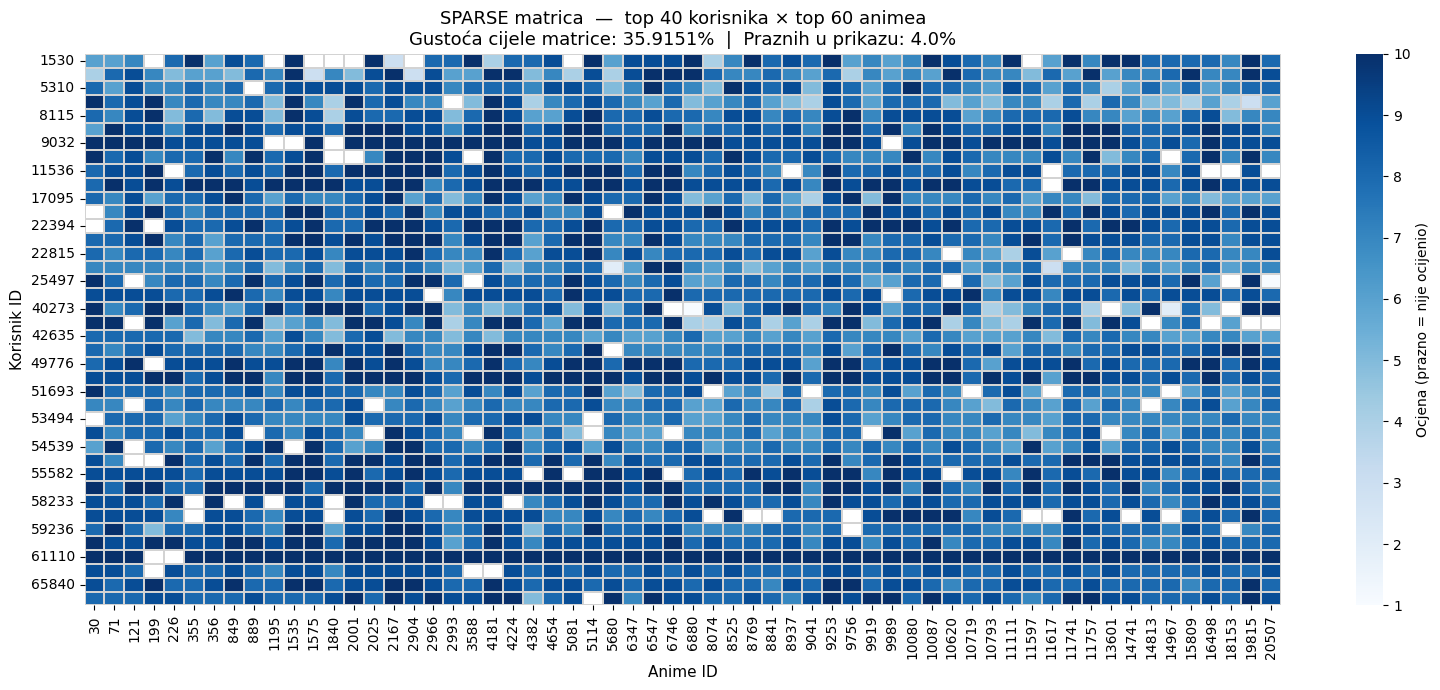


Svako PRAZNO polje = kombinacija korisnik-anime za koju nemamo ocjenu.
SVD faktorizacija će predvidjeti te vrijednosti.


In [49]:
# Top 40 najaktivnijih korisnika i top 60 najpopularnijih animea
top_u = df['user_id'].value_counts().head(40).index
top_a = df['anime_id'].value_counts().head(60).index

# Pivot tabela samo za ovaj podskup
df_sub = df[df['user_id'].isin(top_u) & df['anime_id'].isin(top_a)]
pivot  = df_sub.pivot_table(index='user_id', columns='anime_id', values='rating')
sub    = pivot.fillna(0).values

# Statistike prikaza
praznih_prikaz = pivot.isna().sum().sum()
ukupno_prikaz  = pivot.size
print(f"Podskup za prikaz   : {pivot.shape[0]} korisnika × {pivot.shape[1]} animea")
print(f"Praznih polja       : {praznih_prikaz} / {ukupno_prikaz}  ({praznih_prikaz/ukupno_prikaz*100:.1f}%)")
print(f"Popunjenih polja    : {ukupno_prikaz - praznih_prikaz} / {ukupno_prikaz}  ({(ukupno_prikaz-praznih_prikaz)/ukupno_prikaz*100:.1f}%)")

plt.figure(figsize=(16, 7))
sns.heatmap(
    pivot,
    cmap='Blues',
    linewidths=0.3,
    linecolor='lightgray',
    cbar_kws={'label': 'Ocjena (prazno = nije ocijenio)'},
    vmin=1, vmax=10
)
plt.title(
    f'SPARSE matrica  —  top 40 korisnika × top 60 animea\n'
    f'Gustoća cijele matrice: {gustoca:.4f}%  |  '
    f'Praznih u prikazu: {praznih_prikaz/ukupno_prikaz*100:.1f}%',
    fontsize=13
)
plt.xlabel('Anime ID', fontsize=11)
plt.ylabel('Korisnik ID', fontsize=11)
plt.tight_layout()
plt.show()

print("\nSvako PRAZNO polje = kombinacija korisnik-anime za koju nemamo ocjenu.")
print("SVD faktorizacija će predvidjeti te vrijednosti.")

## 5. SVD faktorizacija

### Teorijska osnova

SVD (Singular Value Decomposition) rastavlja matricu ocjena **R** na tri matrice:

$$R \approx U \cdot \Sigma \cdot V^T$$

| Matrica | Dimenzija | Značenje |
|---------|-----------|----------|
| **U** | korisnici × k | Latentni profil svakog korisnika |
| **Σ** | k × k | Dijagonalna — "jačina" svakog latentnog faktora |
| **V^T** | k × animei | Latentni profil svakog animea |

**k = broj latentnih faktora** (koristimo k=50). Ove latentne dimenzije automatski uče skrivene koncepte poput žanra, stila animacije, ciljne publike — bez da ih mi eksplicitno definiramo.

### Mean-centering

Prije SVD-a radimo **mean-centering** odnosno od svake ocjene oduzimamo prosjek tog korisnika. Razlog za to je što neki korisnici uvijek daju visoke ocjene (8–10), a neki niske (3–5). Bez centriranja SVD uči te razlike u stilu ocjenjivanja umjesto stvarnih preferencija. Nakon rekonstrukcije prosjeci se vraćaju nazad.

### Zašto SVD radi?

Korisnici koji vole slične animee imat će slične redove u U matrici. Animei koji su popularni kod sl

In [50]:
K = 50  # broj latentnih faktora

# Mean-centering
# Svaki korisnik ima drugačiji "baseline", neki uvijek daju visoke ocjene,
# neki niske. SVD radi bolje ako oduzme taj prosjek prije faktorizacije.

user_mean = np.array(sparse_mat.mean(axis=1)).flatten()  # prosjek po korisniku

# Kopija sparse matrice za centriranje
cx = sparse_mat.copy().astype(np.float64).tocsr()

# Oduzmi prosjek korisnika samo od nenultih vrijednosti (ne diramo nule)
for i in range(cx.shape[0]):
    cx.data[cx.indptr[i]:cx.indptr[i+1]] -= user_mean[i]

# SVD na centriranoj matrici
U, sigma, Vt = svds(cx, k=K)

idx   = np.argsort(sigma)[::-1]
U     = U[:, idx]
sigma = sigma[idx]
Vt    = Vt[idx, :]

print(f"U matrica (korisnici × faktori) : {U.shape}")
print(f"Sigma vektor (faktori)          : {sigma.shape}")
print(f"Vt matrica (faktori × animei)   : {Vt.shape}")
print()
print(f"Prvih 10 singularnih vrijednosti: {np.round(sigma[:10], 2)}")
print()
print("Veće singularne vrijednosti = 'važniji' latentni faktori")
print(f"Faktor 1 je najvažniji, faktor {K} najmanje važan.")

# Rekonstrukcija
# Množimo nazad i dodamo prosjeke korisnika koje smo oduzeli
R_hat = U @ np.diag(sigma) @ Vt
R_hat += user_mean.reshape(-1, 1)  # vrati prosjek svakog korisnika
R_hat = np.clip(R_hat, 1, 10)

print(f"\nRekonstruirana matrica R_hat: {R_hat.shape}")
print(f"Min predviđena ocjena: {R_hat.min():.2f}")
print(f"Max predviđena ocjena: {R_hat.max():.2f}")

U matrica (korisnici × faktori) : (2000, 50)
Sigma vektor (faktori)          : (50,)
Vt matrica (faktori × animei)   : (50, 1000)

Prvih 10 singularnih vrijednosti: [2701.25  974.34  730.34  618.97  509.69  473.65  445.62  405.81  377.74
  365.75]

Veće singularne vrijednosti = 'važniji' latentni faktori
Faktor 1 je najvažniji, faktor 50 najmanje važan.

Rekonstruirana matrica R_hat: (2000, 1000)
Min predviđena ocjena: 1.00
Max predviđena ocjena: 10.00


## 6. Vizualizacija: Sparse matrica vs Rekonstruirana matrica

Ovo je ključna vizualizacija zadaće, direktno poređenje:

- **Lijevo (PRIJE):** originalna sparse matrica (puno praznih mjesta, vidljivo je gdje nedostaju ocjene)
- **Desno (POSLIJE):** rekonstruirana matrica (sve ćelije su popunjene predviđenim ocjenama)

Koristimo isti podskup (top korisnici × top animei) za fer poređenje.

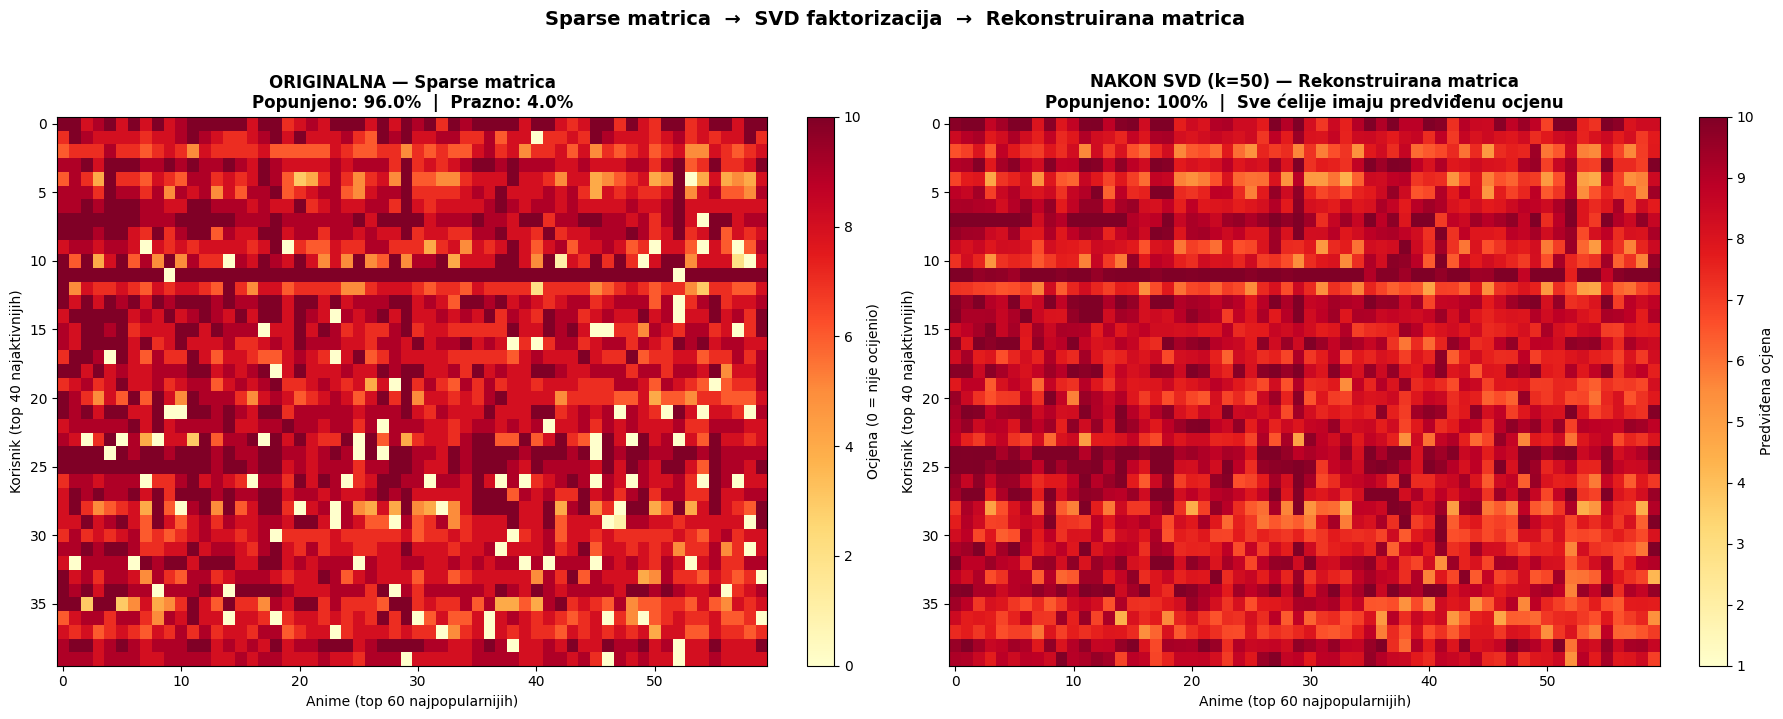

Originalna matrica: 2,303 popunjenih od 2,400 ćelija
Rekonstruirana   : 2,400 popunjenih od 2,400 ćelija
SVD je predvidio ocjene za 97 praznih mjesta!


In [51]:
# Mapiramo top korisnike/animee na njihove indekse u sparse matrici
u_enc2 = {u: i for i, u in enumerate(df['user_id'].unique())}
a_enc2 = {a: i for i, a in enumerate(df['anime_id'].unique())}

u_idx = [u_enc2[u] for u in top_u if u in u_enc2]
a_idx = [a_enc2[a] for a in top_a if a in a_enc2]

# Izvučemo isti podskup iz originalne i rekonstruirane matrice
sub_orig = sparse_mat[u_idx, :][:, a_idx].toarray()  # originalna (sa nulama)
sub_hat  = R_hat[u_idx, :][:, a_idx]                  # rekonstruirana (popunjena)

gustoca_orig = np.count_nonzero(sub_orig) / sub_orig.size * 100
gustoca_hat  = np.count_nonzero(sub_hat)  / sub_hat.size  * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lijevo: originalna sparse
im0 = axes[0].imshow(sub_orig, aspect='auto', cmap='YlOrRd', vmin=0, vmax=10,
                     interpolation='nearest')
axes[0].set_title(
    f'ORIGINALNA — Sparse matrica\n'
    f'Popunjeno: {gustoca_orig:.1f}%  |  Prazno: {100-gustoca_orig:.1f}%',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Anime (top 60 najpopularnijih)', fontsize=10)
axes[0].set_ylabel('Korisnik (top 40 najaktivnijih)', fontsize=10)
plt.colorbar(im0, ax=axes[0], label='Ocjena (0 = nije ocijenio)', fraction=0.046)

# Desno: rekonstruirana
im1 = axes[1].imshow(sub_hat, aspect='auto', cmap='YlOrRd', vmin=1, vmax=10,
                     interpolation='nearest')
axes[1].set_title(
    f'NAKON SVD (k={K}) — Rekonstruirana matrica\n'
    f'Popunjeno: 100%  |  Sve ćelije imaju predviđenu ocjenu',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Anime (top 60 najpopularnijih)', fontsize=10)
axes[1].set_ylabel('Korisnik (top 40 najaktivnijih)', fontsize=10)
plt.colorbar(im1, ax=axes[1], label='Predviđena ocjena', fraction=0.046)

plt.suptitle(
    'Sparse matrica  →  SVD faktorizacija  →  Rekonstruirana matrica',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print(f"Originalna matrica: {np.count_nonzero(sub_orig):,} popunjenih od {sub_orig.size:,} ćelija")
print(f"Rekonstruirana   : {sub_hat.size:,} popunjenih od {sub_hat.size:,} ćelija")
print(f"SVD je predvidio ocjene za {sub_orig.size - np.count_nonzero(sub_orig):,} praznih mjesta!")

## 7. Generiranje preporuka

Sada koristimo rekonstruiranu matricu za stvarne preporuke.

**Logika:**
1. Za odabranog korisnika, pogledamo koje animee **nije** ocijenio (nulte vrijednosti u originalnoj matrici)
2. Za ta prazna mjesta, iz rekonstruirane matrice R_hat čitamo **predviđenu ocjenu**
3. Sortiramo po predviđenoj ocjeni i vraćamo top N


In [52]:
# 7. Generiranje preporuka

def preporuke(user_idx, sparse_mat, R_hat, n=10):
    vec_originalan = sparse_mat[user_idx].toarray().flatten()
    vec_hat        = R_hat[user_idx]
    nevidjen = np.where(vec_originalan == 0)[0]
    pred_oc  = vec_hat[nevidjen]
    sort_idx = np.argsort(pred_oc)[::-1][:n]
    return nevidjen[sort_idx], pred_oc[sort_idx]

# Nađi korisnika koji ima najviše ocjena (najpouzdanije preporuke)
aktivnost = np.diff(sparse_mat.indptr)  # broj ocjena po korisniku
user_idx  = int(np.argmax(aktivnost))   # korisnik s najviše ocjena

top_idx, top_ocj = preporuke(user_idx, sparse_mat, R_hat)

n_gledao = sparse_mat[user_idx].nnz
print(f"Korisnik #{user_idx} je ocijenio {n_gledao} animea.")
print(f"\n{'Rang':<6} {'Anime ID':<12} {'Predviđena ocjena'}")
print("-" * 35)
for i, (ai, oc) in enumerate(zip(top_idx, top_ocj)):
    print(f"  {i+1:<5} {ai:<12} {oc:.2f} / 10")

Korisnik #1581 je ocijenio 933 animea.

Rang   Anime ID     Predviđena ocjena
-----------------------------------
  1     173          9.72 / 10
  2     367          9.48 / 10
  3     813          9.17 / 10
  4     982          9.17 / 10
  5     362          8.99 / 10
  6     809          8.94 / 10
  7     817          8.93 / 10
  8     351          8.88 / 10
  9     597          8.79 / 10
  10    947          8.78 / 10


## 8. Vizualizacija preporuka

Bar chart prikazuje top-10 animea koje model preporučuje korisniku, sortirano po predviđenoj ocjeni.

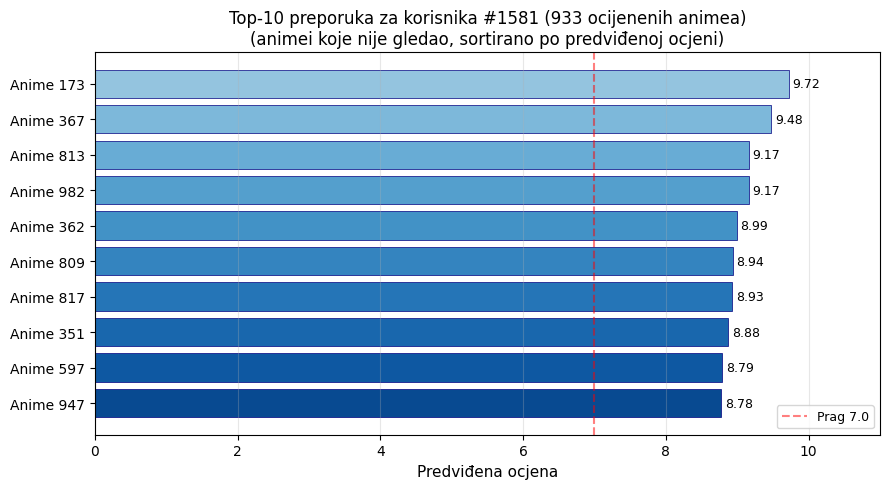

In [53]:
# 8. Vizualizacija preporuka
plt.figure(figsize=(9, 5))
labels = [f'Anime {ai}' for ai in top_idx]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_ocj)))
bars = plt.barh(labels[::-1], top_ocj[::-1], color=colors[::-1], edgecolor='navy', lw=0.5)
for bar, oc in zip(bars, top_ocj[::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{oc:.2f}', va='center', fontsize=9)
plt.xlabel('Predviđena ocjena', fontsize=11)
plt.title(f'Top-10 preporuka za korisnika #{user_idx} ({n_gledao} ocijenenih animea)\n'
          f'(animei koje nije gledao, sortirano po predviđenoj ocjeni)', fontsize=12)
plt.xlim(0, 11)
plt.axvline(7, color='red', linestyle='--', alpha=0.5, label='Prag 7.0')
plt.legend(fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()